<a href="https://colab.research.google.com/github/kimshy22/AI-Battery-SOH-Monitoring/blob/main/B0007_final_model_training_and_export.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/B007_data/B0007_cycle_level.csv"

df = pd.read_csv(file_path)
df = df.sort_values("cycle_id").reset_index(drop=True)

df.head()

Mounted at /content/drive


,battery_id,cycle_id,config_name,event_id,event_type,valid_for_direct_soh,row_mode,measured_capacity_ah,corrected_capacity_ah,estimated_full_capacity_ah,...,max_voltage_v,voltage_drop_v,avg_discharge_current_a,avg_charge_current_a,avg_temperature_c,soc_start,soc_end,soc_window,needs_soc_window_correction,notes
0,B0007,2,nasa_b0007,2,full_discharge,True,discharge,1.918465,1.918465,1.918465,...,3.985606,1.839631,1.990169,0.0,32.375164,NaN,NaN,NaN,False,Looks like a full discharge event.
1,B0007,4,nasa_b0007,5,full_discharge,True,discharge,1.908111,1.908111,1.908111,...,3.990235,1.879219,1.989754,0.0,32.505157,NaN,NaN,NaN,False,Looks like a full discharge event.
2,B0007,6,nasa_b0007,8,full_discharge,True,discharge,1.908103,1.908103,1.908103,...,3.992171,1.967062,1.989869,0.0,32.471508,NaN,NaN,NaN,False,Looks like a full discharge event.
3,B0007,8,nasa_b0007,11,full_discharge,True,discharge,1.908258,1.908258,1.908258,...,3.993218,2.070676,1.989920,0.0,32.360627,NaN,NaN,NaN,False,Looks like a full discharge event.
4,B0007,10,nasa_b0007,14,full_discharge,True,discharge,1.906847,1.906847,1.906847,...,3.993959,2.122800,1.989604,0.0,32.270931,NaN,NaN,NaN,False,Looks like a full discharge event.


In [ ]:
important_cols = [
    "cycle_id",
    "corrected_capacity_ah",
    "soh_percent_smoothed",
    "duration_s",
    "avg_discharge_current_a",
    "avg_temperature_c",
    "start_voltage_v",
    "end_voltage_v"
]

df = df[important_cols].dropna().reset_index(drop=True)

df["soh_current"] = df["soh_percent_smoothed"]

df["capacity_ratio"] = (
    df["corrected_capacity_ah"] / df["corrected_capacity_ah"].iloc[0]
)

df["voltage_drop_v"] = df["start_voltage_v"] - df["end_voltage_v"]

df["delta_soh"] = df["soh_percent_smoothed"].diff()
df["recent_slope_3"] = df["delta_soh"].rolling(window=3).mean()

df = df.dropna().reset_index(drop=True)

df.head()

,cycle_id,corrected_capacity_ah,soh_percent_smoothed,duration_s,avg_discharge_current_a,avg_temperature_c,start_voltage_v,end_voltage_v,soh_current,capacity_ratio,voltage_drop_v,delta_soh,recent_slope_3
0,8,1.908258,95.413493,3433.282,1.989920,32.360627,3.993218,1.922542,95.413493,0.994679,2.070676,-0.003383,-0.169924
1,10,1.906847,95.353002,3431.328,1.989604,32.270931,3.993959,1.871159,95.353002,0.993944,2.122800,-0.060491,-0.043396
2,12,1.897065,94.928211,3413.250,1.989797,32.265623,3.994485,2.175687,94.928211,0.988845,1.818799,-0.424791,-0.162889
3,14,1.896223,94.828720,3412.204,1.989603,32.332517,3.995565,2.111789,94.828720,0.988406,1.883776,-0.099491,-0.194924
4,16,1.897810,94.881221,3415.234,1.989511,32.324822,3.997744,2.026251,94.881221,0.989233,1.971493,0.052501,-0.157260


In [ ]:
lstm_feature_cols = [
    "soh_current",
    "capacity_ratio",
    "corrected_capacity_ah",
    "recent_slope_3",
    "avg_temperature_c",
    "voltage_drop_v"
]

WINDOW_SIZE = 5
EOL_THRESHOLD = 70.0

save_dir = "/content/drive/MyDrive/B007_data/final_deployment_artifacts"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
def create_lstm_sequences(df, feature_cols, target_col, window_size=5):
    X, y, current_soh, cycle_ids = [], [], [], []

    feature_values = df[feature_cols].values
    target_values = df[target_col].values
    soh_values = df["soh_current"].values
    cycles = df["cycle_id"].values

    for i in range(window_size, len(df)):
        X.append(feature_values[i-window_size:i])
        y.append(target_values[i])
        current_soh.append(soh_values[i])
        cycle_ids.append(cycles[i])

    return np.array(X), np.array(y), np.array(current_soh), np.array(cycle_ids)

In [ ]:
def build_lstm_model(window_size, num_features):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(8, return_sequences=False),
        Dropout(0.20),
        Dense(8, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
def train_save_lstm_for_horizon(df, horizon):
    print("=" * 60)
    print(f"Training LSTM for {horizon}-cycle ahead prediction")
    print("=" * 60)

    data = df.copy()

    data["target_soh_future"] = data["soh_percent_smoothed"].shift(-horizon)
    data["target_delta_future"] = data["target_soh_future"] - data["soh_current"]

    data = data.dropna().reset_index(drop=True)

    X, y, current_soh_arr, cycle_arr = create_lstm_sequences(
        data,
        lstm_feature_cols,
        "target_delta_future",
        window_size=WINDOW_SIZE
    )

    n = len(X)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]

    current_soh_test = current_soh_arr[val_end:]
    cycle_test = cycle_arr[val_end:]

    num_features = X_train.shape[2]

    feature_scaler = StandardScaler()

    X_train_scaled = feature_scaler.fit_transform(
        X_train.reshape(-1, num_features)
    ).reshape(X_train.shape)

    X_val_scaled = feature_scaler.transform(
        X_val.reshape(-1, num_features)
    ).reshape(X_val.shape)

    X_test_scaled = feature_scaler.transform(
        X_test.reshape(-1, num_features)
    ).reshape(X_test.shape)

    target_scaler = StandardScaler()

    y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1))
    y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1))

    model = build_lstm_model(WINDOW_SIZE, num_features)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=300,
        batch_size=4,
        callbacks=[early_stop],
        verbose=1
    )

    y_pred_scaled = model.predict(X_test_scaled)
    y_pred_delta = target_scaler.inverse_transform(y_pred_scaled).flatten()

    true_future_soh = current_soh_test + y_test
    predicted_future_soh = current_soh_test + y_pred_delta

    mae = mean_absolute_error(true_future_soh, predicted_future_soh)
    rmse = np.sqrt(mean_squared_error(true_future_soh, predicted_future_soh))

    print()
    print(f"LSTM {horizon}-cycle result")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")

    weights_path = os.path.join(
        save_dir,
        f"b0007_lstm_h{horizon}_weights.weights.h5"
    )

    feature_scaler_path = os.path.join(
        save_dir,
        f"b0007_feature_scaler_h{horizon}.pkl"
    )

    target_scaler_path = os.path.join(
        save_dir,
        f"b0007_target_scaler_h{horizon}.pkl"
    )

    model.save_weights(weights_path)
    joblib.dump(feature_scaler, feature_scaler_path)
    joblib.dump(target_scaler, target_scaler_path)

    print()
    print("Saved:")
    print(weights_path)
    print(feature_scaler_path)
    print(target_scaler_path)

    return {
        "horizon": horizon,
        "mae": mae,
        "rmse": rmse,
        "weights_path": weights_path,
        "feature_scaler_path": feature_scaler_path,
        "target_scaler_path": target_scaler_path,
        "history": history.history
    }

In [ ]:
results = []

for horizon in [5, 10, 20]:
    result = train_save_lstm_for_horizon(df, horizon)
    results.append(result)

results_df = pd.DataFrame([
    {
        "horizon": r["horizon"],
        "mae": r["mae"],
        "rmse": r["rmse"]
    }
    for r in results
])

results_df

Training LSTM for 5-cycle ahead prediction
Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.9927 - mae: 0.7823 - val_loss: 0.6276 - val_mae: 0.6514
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9788 - mae: 0.7699 - val_loss: 0.6219 - val_mae: 0.6481
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9727 - mae: 0.7675 - val_loss: 0.6175 - val_mae: 0.6455
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0080 - mae: 0.7872 - val_loss: 0.6130 - val_mae: 0.6433
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9840 - mae: 0.7788 - val_loss: 0.6091 - val_mae: 0.6405
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9985 - mae: 0.7877 - val_loss: 0.6047 - val_mae: 0.6412
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9851 - mae: 0.7769 - val_loss: 0.6006 - val_mae: 0.6450
Epoch 8/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9553 - mae: 0.7579 - val_loss: 0.5973 - val_mae: 0.6488
Epoch 9/300
27/2

,horizon,mae,rmse
0,5,0.360009,0.455970
1,10,0.465730,0.567326
2,20,1.410760,1.463244


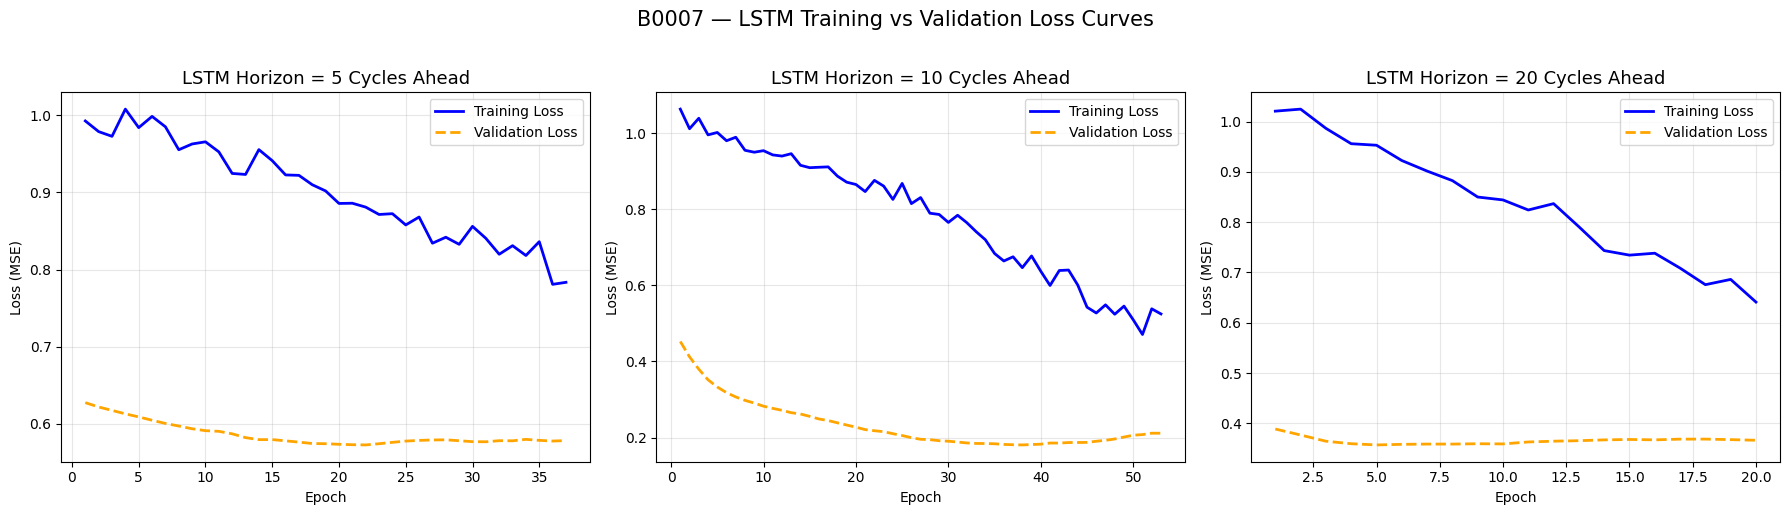

Saved loss curves.


In [ ]:
# === Plot Training vs Validation Loss for each horizon ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, result in enumerate(results):
    horizon = result["horizon"]
    history = result["history"]

    train_loss = history["loss"]
    val_loss   = history["val_loss"]
    epochs     = range(1, len(train_loss) + 1)

    ax = axes[i]
    ax.plot(epochs, train_loss, label="Training Loss",   color="blue",   linewidth=2)
    ax.plot(epochs, val_loss,   label="Validation Loss", color="orange", linewidth=2, linestyle="--")

    ax.set_title(f"LSTM Horizon = {horizon} Cycles Ahead", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("B0007 — LSTM Training vs Validation Loss Curves", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/B007_data/lstm_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved loss curves.")

In [ ]:
results_df

,horizon,mae,rmse
0,5,0.360009,0.455970
1,10,0.465730,0.567326
2,20,1.410760,1.463244


In [ ]:
print(df.columns.tolist())
print(df[["cycle_id", "soh_current", "recent_slope_3"]].head(10))

['cycle_id', 'corrected_capacity_ah', 'soh_percent_smoothed', 'duration_s', 'avg_discharge_current_a', 'avg_temperature_c', 'start_voltage_v', 'end_voltage_v', 'soh_current', 'capacity_ratio', 'voltage_drop_v', 'delta_soh', 'recent_slope_3']
   cycle_id  soh_current  recent_slope_3
0         8    95.413493       -0.169924
1        10    95.353002       -0.043396
2        12    94.928211       -0.162889
3        14    94.828720       -0.194924
4        16    94.881221       -0.157260
5        18    94.853289       -0.024974
6        20    94.871139        0.014140
7        22    94.870455       -0.003589
8        25    94.429565       -0.141241
9        27    94.342027       -0.176371


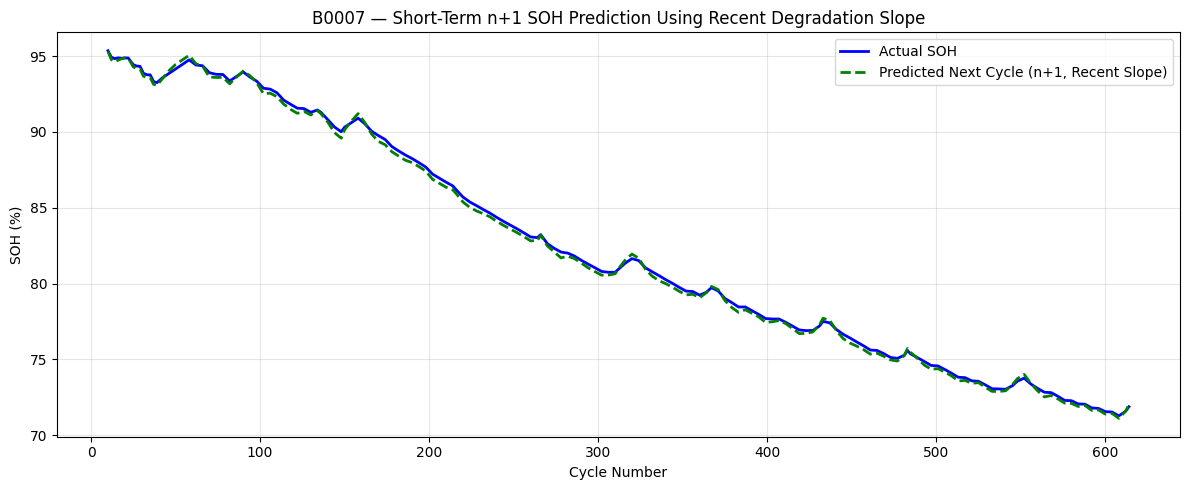

In [ ]:
# === Show recent slope n+1 prediction on B0007 data ===

df_plot = df.copy()

# recent_slope_3 is already in your dataframe from feature engineering
# It represents the average SOH change over the last 3 cycles
# Predicting next cycle = current SOH + recent slope

df_plot["predicted_next_soh"] = df_plot["soh_current"] + df_plot["recent_slope_3"]

# Only plot from cycle 10 onwards so the slope has enough history
df_plot = df_plot[df_plot["cycle_id"] >= 10]

plt.figure(figsize=(12, 5))
plt.plot(df_plot["cycle_id"], df_plot["soh_current"],
         label="Actual SOH", color="blue", linewidth=2)
plt.plot(df_plot["cycle_id"], df_plot["predicted_next_soh"],
         label="Predicted Next Cycle (n+1, Recent Slope)",
         color="green", linewidth=2, linestyle="--")

plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.title("B0007 — Short-Term n+1 SOH Prediction Using Recent Degradation Slope")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/B007_data/n1_prediction.png", dpi=150)
plt.show()

In [ ]:
# === Calculate n+1 prediction error ===

# Drop rows where recent_slope_3 is NaN (first few cycles)
df_eval = df_plot.dropna(subset=["recent_slope_3", "soh_current"]).copy()

df_eval["predicted_next_soh"] = df_eval["soh_current"] + df_eval["recent_slope_3"]

# Shift actual SOH by 1 to get the TRUE next cycle SOH
df_eval["true_next_soh"] = df_eval["soh_current"].shift(-1)

# Drop last row since it has no next cycle
df_eval = df_eval.dropna(subset=["true_next_soh"])

# Calculate error per cycle
df_eval["error"] = df_eval["true_next_soh"] - df_eval["predicted_next_soh"]
df_eval["abs_error"] = df_eval["error"].abs()

# Summary metrics
mae  = df_eval["abs_error"].mean()
rmse = np.sqrt((df_eval["error"] ** 2).mean())

print("=== n+1 Recent Slope Prediction Error ===")
print(f"MAE:  {mae:.4f} %")
print(f"RMSE: {rmse:.4f} %")
print(f"Max error: {df_eval['abs_error'].max():.4f} %")
print(f"Min error: {df_eval['abs_error'].min():.4f} %")
print()
print(df_eval[["cycle_id", "soh_current", "predicted_next_soh",
               "true_next_soh", "abs_error"]].head(15))

=== n+1 Recent Slope Prediction Error ===
MAE:  0.1901 %
RMSE: 0.2519 %
Max error: 0.7244 %
Min error: 0.0000 %

    cycle_id  soh_current  predicted_next_soh  true_next_soh  abs_error
1         10    95.353002           95.309606      94.928211   0.381395
2         12    94.928211           94.765322      94.828720   0.063397
3         14    94.828720           94.633796      94.881221   0.247426
4         16    94.881221           94.723961      94.853289   0.129328
5         18    94.853289           94.828315      94.871139   0.042824
6         20    94.871139           94.885279      94.870455   0.014825
7         22    94.870455           94.866866      94.429565   0.437301
8         25    94.429565           94.288323      94.342027   0.053704
9         27    94.342027           94.165656      94.320591   0.154935
10        29    94.320591           94.137304      93.861798   0.275505
11        31    93.861798           93.672543      93.768678   0.096135
12        33    93.7686

In [ ]:
deployment_config = {
    "battery_id": "B0007",
    "chemistry": "LCO",
    "window_size": WINDOW_SIZE,
    "eol_threshold": EOL_THRESHOLD,
    "feature_cols": lstm_feature_cols,
    "target_type": "delta_soh",
    "short_horizon_model": {
        "horizon": 1,
        "method": "recent_slope_3"
    },
    "lstm_models": {
        "5": {
            "weights": "b0007_lstm_h5_weights.weights.h5",
            "feature_scaler": "b0007_feature_scaler_h5.pkl",
            "target_scaler": "b0007_target_scaler_h5.pkl"
        },
        "10": {
            "weights": "b0007_lstm_h10_weights.weights.h5",
            "feature_scaler": "b0007_feature_scaler_h10.pkl",
            "target_scaler": "b0007_target_scaler_h10.pkl"
        },
        "20": {
            "weights": "b0007_lstm_h20_weights.weights.h5",
            "feature_scaler": "b0007_feature_scaler_h20.pkl",
            "target_scaler": "b0007_target_scaler_h20.pkl"
        }
    },
    "rul_model": {
        "method": "rolling_slope",
        "rolling_window": 5
    },
    "architecture": {
        "lstm_units": 8,
        "dropout": 0.20,
        "dense_units": 8,
        "learning_rate": 0.0003
    }
}

config_path = os.path.join(save_dir, "b0007_deployment_config.json")

with open(config_path, "w") as f:
    json.dump(deployment_config, f, indent=4)

print("Saved config:", config_path)

Saved config: /content/drive/MyDrive/B007_data/final_deployment_artifacts/b0007_deployment_config.json
